In [1]:
import pandas as pd

# Load Datasets
wdi_raw = pd.read_csv("world_bank_data_2025.csv")
climate_raw = pd.read_csv("imf_ndgain.csv")

# 1. Dataset preparation

## 1.1 World Bank World Development Indicators

In [2]:
# Quick inspection of raw WDI dataset
wdi_raw.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [3]:
# Check dimensions
print(f"Dataset shape: {wdi_raw.shape}")

# Inspect columns and data types
wdi_raw.dtypes

Dataset shape: (3472, 16)


country_name                        object
country_id                          object
year                                 int64
Inflation (CPI %)                  float64
GDP (Current USD)                  float64
GDP per Capita (Current USD)       float64
Unemployment Rate (%)              float64
Interest Rate (Real, %)            float64
Inflation (GDP Deflator, %)        float64
GDP Growth (% Annual)              float64
Current Account Balance (% GDP)    float64
Government Expense (% of GDP)      float64
Government Revenue (% of GDP)      float64
Tax Revenue (% of GDP)             float64
Gross National Income (USD)        float64
Public Debt (% of GDP)             float64
dtype: object

In [4]:
# Check the total number of countries by country name
print(f"Number of countries: {wdi_raw['country_name'].nunique()}")

# Inspect country names and id
print(wdi_raw[['country_name','country_id']].drop_duplicates().sort_values('country_name'))

Number of countries: 217
               country_name country_id
16              Afghanistan         af
48                  Albania         al
880                 Algeria         dz
128          American Samoa         as
64                  Andorra         ad
...                     ...        ...
3328  Virgin Islands (U.S.)         vi
2576     West Bank and Gaza         ps
3408            Yemen, Rep.         ye
3440                 Zambia         zm
3456               Zimbabwe         zw

[217 rows x 2 columns]


In [5]:
# Confirm the years covered in dataset
print(f"Years covered in WDI dataset: {wdi_raw['year'].unique()}")

Years covered in WDI dataset: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025]


In [6]:
# Filter countries down to 11 Southeast Asian economies and convert 2-letter ISO codes to 3-letter ISO3 codes
# Import converter library
import country_converter as coco

# List of 2-letter ISO codes for ASEAN economies
SEA_ISO2 = [
    'bn',  # Brunei
    'kh',  # Cambodia
    'id',  # Indonesia
    'la',  # Laos
    'my',  # Malaysia
    'mm',  # Myanmar
    'ph',  # Philippines
    'sg',  # Singapore
    'th',  # Thailand
    'tl',  # Timor-Leste
    'vn'   # Vietnam
]

# Filter dataset using the 2-letter 'country_id' column
wdi_sea = wdi_raw[wdi_raw['country_id'].isin(SEA_ISO2)].copy()

# Convert the 2-letter codes to 3-letter ISO3 codes
cc = coco.CountryConverter()
wdi_sea['ISO3'] = cc.convert(names=wdi_sea['country_id'], to='ISO3')

# Verify conversion
print(wdi_sea[['ISO3','country_name','country_id']].drop_duplicates().sort_values('country_name'))

# Verify the number of ASEAN countries are exactly 11
print(f"Number of countries: {wdi_sea['country_name'].nunique()}")

     ISO3       country_name country_id
448   BRN  Brunei Darussalam         bn
1632  KHM           Cambodia         kh
1392  IDN          Indonesia         id
1712  LAO            Lao PDR         la
2208  MYS           Malaysia         my
2080  MMR            Myanmar         mm
2448  PHL        Philippines         ph
2720  SGP          Singapore         sg
3040  THA           Thailand         th
3088  TLS        Timor-Leste         tl
3344  VNM           Viet Nam         vn
Number of countries: 11


In [7]:
wdi_sea.sample(11)

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP),ISO3
2720,Singapore,sg,2010,2.823661,2.398080e+11,47236.683085,4.120,4.225382,1.107809,14.519750,22.933347,12.412804,16.779064,12.785824,2.372169e+11,101.449782,SGP
1723,Lao PDR,la,2021,3.755620,1.882715e+10,2526.051050,2.066,NaN,3.713448,2.528351,2.292628,10.762793,12.820865,10.391022,1.775493e+10,NaN,LAO
3051,Thailand,th,2021,1.230395,5.062565e+11,7058.069500,1.215,1.266497,1.771072,1.568182,-2.117994,25.129925,19.203627,15.061418,4.886722e+11,58.504309,THA
3052,Thailand,th,2022,6.077412,4.956452e+11,6909.359975,0.940,-1.554557,4.766996,2.462769,-3.462520,22.232021,18.976822,15.139034,4.813904e+11,60.349858,THA
2208,Malaysia,my,2010,1.622852,2.550176e+11,8899.345055,3.390,-2.113277,7.266846,7.424847,10.055678,18.231925,19.435872,13.332195,2.469052e+11,49.559823,MYS
1399,Indonesia,id,2017,3.808798,1.015619e+12,3798.883262,3.783,6.501564,4.292678,5.069786,-1.594657,NaN,NaN,NaN,9.834380e+11,NaN,IDN
1637,Cambodia,kh,2015,1.223932,2.417417e+10,1547.320104,0.393,NaN,3.069359,7.207035,-6.612213,8.993962,12.378528,10.888493,2.317797e+10,NaN,KHM
1394,Indonesia,id,2012,4.279500,9.178699e+11,3632.272540,4.468,7.750189,3.753879,6.030051,-2.660274,NaN,NaN,NaN,8.919615e+11,NaN,IDN
1636,Cambodia,kh,2014,3.855689,2.204146e+10,1431.563965,0.692,NaN,3.299369,8.000321,-6.551764,9.436420,12.563237,11.083788,2.111028e+10,NaN,KHM
1725,Lao PDR,la,2023,31.230134,1.584316e+10,2066.949798,1.188,NaN,24.421720,3.745681,2.553296,NaN,NaN,NaN,1.468569e+10,NaN,LAO


## 1.2 IMF-Adapted ND-GAIN

In [8]:
# Quick inspection of IMF dataset
climate_raw.head()

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,DECIMALS_DISPLAYED,UNIT,OVERLAP,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,IMF.STA:NDGAIN(1.0.1),NRU.VSC_NUM.A,OBS_VALUE,"Naoero, Republic of","Vulnerability score, Capacity",Annual,Units,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:NDGAIN(1.0.1),SMR.VSC_NUM.A,OBS_VALUE,"San Marino, Republic of","Vulnerability score, Capacity",Annual,Units,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:NDGAIN(1.0.1),KIR.RSS_NUM.A,OBS_VALUE,Kiribati,"Readiness score, Social",Annual,Units,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IMF.STA:NDGAIN(1.0.1),KNA.VSC_NUM.A,OBS_VALUE,St. Kitts and Nevis,"Vulnerability score, Capacity",Annual,Units,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:NDGAIN(1.0.1),FSM.VSC_NUM.A,OBS_VALUE,"Micronesia, Federated States of","Vulnerability score, Capacity",Annual,Units,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Verify dimensions: 
print(f"Dataset shape: {climate_raw.shape}")

# Inspect column names and data types
climate_raw.dtypes

Dataset shape: (3072, 46)


DATASET                     object
SERIES_CODE                 object
OBS_MEASURE                 object
COUNTRY                     object
INDICATOR                   object
FREQUENCY                   object
SCALE                       object
DECIMALS_DISPLAYED         float64
UNIT                       float64
OVERLAP                    float64
COUNTRY_COVERAGE           float64
TIME_COVERAGE              float64
DOI                        float64
FULL_DESCRIPTION           float64
AUTHOR                     float64
PUBLISHER                   object
DEPARTMENT                  object
CONTACT_POINT               object
TOPIC                      float64
TOPIC_DATASET               object
KEYWORDS                   float64
KEYWORDS_DATASET            object
LANGUAGE                    object
PUBLICATION_DATE            object
UPDATE_DATE                 object
METHODOLOGY                float64
METHODOLOGY_NOTES          float64
ACCESS_SHARING_LEVEL        object
ACCESS_SHARING_NOTES

In [10]:
# Check the total number of countries by country name
print(f"Number of countries: {climate_raw['COUNTRY'].nunique()}")

# Inspect country names only as there is no id or iso code used
print(climate_raw[['COUNTRY']].drop_duplicates().sort_values('COUNTRY'))

Number of countries: 192
                                  COUNTRY
48       Afghanistan, Islamic Republic of
142                               Albania
120                               Algeria
5                Andorra, Principality of
147                                Angola
...                                   ...
2712  Venezuela, República Bolivariana de
2689                              Vietnam
2688                   Yemen, Republic of
2692                               Zambia
2691                             Zimbabwe

[192 rows x 1 columns]


In [11]:
# Check if all 11 Southeast Asian countries are present in dataset directly using ISO3 codes

ASEAN_ISO3 = [
    'BRN', 'KHM', 'IDN', 'LAO', 'MYS', 
    'MMR', 'PHL', 'SGP', 'THA', 'TLS', 'VNM'
]

climate_raw['ISO3'] = cc.convert(names=climate_raw['COUNTRY'], to='ISO3')

# Filter directly using the ISO3 codes
climate_sea = climate_raw[climate_raw['ISO3'].isin(ASEAN_ISO3)].copy()

# Verify all 11 countries are captured
found_countries = climate_sea['ISO3'].unique()
print(f"Captured {len(found_countries)} out of 11 countries:")
print(found_countries)

Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex
Naoero, Republic of not found in regex


Captured 11 out of 11 countries:
['TLS' 'BRN' 'KHM' 'IDN' 'LAO' 'MYS' 'MMR' 'PHL' 'SGP' 'THA' 'VNM']


In [12]:
# Verify the number of ASEAN countries are exactly 11
print(climate_sea[['ISO3','COUNTRY']].drop_duplicates().sort_values('COUNTRY'))

print(f"Number of countries: {climate_sea['COUNTRY'].nunique()}")

     ISO3                              COUNTRY
405   BRN                    Brunei Darussalam
525   KHM                             Cambodia
1024  IDN                            Indonesia
1282  LAO     Lao People's Democratic Republic
1411  MYS                             Malaysia
1815  MMR                              Myanmar
1924  PHL                          Philippines
2177  SGP                            Singapore
2442  THA                             Thailand
17    TLS  Timor-Leste, Democratic Republic of
2689  VNM                              Vietnam
Number of countries: 11


In [13]:
# Check columns
climate_sea.columns

Index(['DATASET', 'SERIES_CODE', 'OBS_MEASURE', 'COUNTRY', 'INDICATOR',
       'FREQUENCY', 'SCALE', 'DECIMALS_DISPLAYED', 'UNIT', 'OVERLAP',
       'COUNTRY_COVERAGE', 'TIME_COVERAGE', 'DOI', 'FULL_DESCRIPTION',
       'AUTHOR', 'PUBLISHER', 'DEPARTMENT', 'CONTACT_POINT', 'TOPIC',
       'TOPIC_DATASET', 'KEYWORDS', 'KEYWORDS_DATASET', 'LANGUAGE',
       'PUBLICATION_DATE', 'UPDATE_DATE', 'METHODOLOGY', 'METHODOLOGY_NOTES',
       'ACCESS_SHARING_LEVEL', 'ACCESS_SHARING_NOTES',
       'SECURITY_CLASSIFICATION', 'SHORT_SOURCE_CITATION',
       'FULL_SOURCE_CITATION', 'LICENSE', 'SUGGESTED_CITATION',
       'KEY_INDICATOR', 'SERIES_NAME', '2015', '2016', '2017', '2018', '2019',
       '2020', '2021', '2022', '2023', '2024', 'ISO3'],
      dtype='object')

In [14]:
# Reshape dataset
# Define the year columns present
year_cols = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

# Melt year columns into long format
climate_long = pd.melt(
    climate_sea,
    id_vars=['ISO3', 'COUNTRY', 'INDICATOR'], # Keep key identifiers
    value_vars=year_cols,
    var_name='year',
    value_name='Value'
)

# Check conversion
climate_long.head()

,ISO3,COUNTRY,INDICATOR,year,Value
0,TLS,"Timor-Leste, Democratic Republic of","Readiness score, Governance",2015,NaN
1,TLS,"Timor-Leste, Democratic Republic of","Vulnerability score, Capacity",2015,NaN
2,TLS,"Timor-Leste, Democratic Republic of","Vulnerability score, Infrastructure",2015,NaN
3,BRN,Brunei Darussalam,"Vulnerability score, Food",2015,0.451522
4,BRN,Brunei Darussalam,IMF-Adapted Readiness score,2015,0.566326


In [15]:
# Convert year and value to numeric types
climate_long['year'] = climate_long['year'].astype(int)
climate_long['Value'] = pd.to_numeric(climate_long['Value'], errors='coerce')

# Pivot indicators into columns to create one row per country-year with separate columns for each climate metric
climate_tidy = climate_long.pivot_table(
    index=['ISO3', 'year'],
    columns='INDICATOR',
    values='Value',
    aggfunc='first'
).reset_index()

# Clean up column names
climate_tidy.columns.name = None

# Check the transformed structure
print("Tidy DataFrame Shape:", climate_tidy.shape)
climate_tidy.head()

Tidy DataFrame Shape: (110, 18)


,ISO3,year,IMF-Adapted ND-GAIN Index,IMF-Adapted Readiness score,"Readiness score, Governance","Readiness score, IMF-Adapted Economic","Readiness score, Social",Vulnerability score,"Vulnerability score, Capacity","Vulnerability score, Ecosystems","Vulnerability score, Exposure","Vulnerability score, Food","Vulnerability score, GDP-Adjusted (Delta)","Vulnerability score, Habitat","Vulnerability score, Heath","Vulnerability score, Infrastructure","Vulnerability score, Sensitivity","Vulnerability score, Water"
0,BRN,2015,0.580117,0.566326,0.646280,0.747399,0.305299,0.406092,0.578689,0.416550,0.404785,0.451522,0.091295,0.521192,0.348172,0.411594,0.271921,0.287522
1,BRN,2016,0.572457,0.550386,0.636916,0.711653,0.302588,0.405473,0.573852,0.404511,0.404785,0.458704,0.073790,0.520958,0.349479,0.411594,0.274048,0.287590
2,BRN,2017,0.574411,0.553825,0.655912,0.720008,0.285555,0.405003,0.579277,0.401461,0.404785,0.448473,0.087264,0.527094,0.353740,0.411594,0.266798,0.287654
3,BRN,2018,0.586695,0.576609,0.662010,0.721515,0.346303,0.403219,0.580708,0.398411,0.404785,0.440185,0.095259,0.533393,0.348019,0.411594,0.260695,0.287714
4,BRN,2019,0.576467,0.556580,0.653939,0.734085,0.281717,0.403646,0.580736,0.407077,0.404785,0.433736,0.107464,0.533678,0.348019,0.411594,0.262060,0.287771


## 1.3 Merge datasets

In [16]:
# Check year coverage before merging
print("WDI Years:", (wdi_sea['year'].unique()))
print("Climate Years:", (climate_tidy['year'].unique()))

WDI Years: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025]
Climate Years: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [17]:
# Ensure the year columns in both datasets are integer
wdi_sea['year'] = wdi_sea['year'].astype(int)
climate_tidy['year'] = climate_tidy['year'].astype(int)

# Merge on ISO3 and year
merged_df = pd.merge(wdi_sea, climate_tidy, on=['ISO3', 'year'], how='inner')
merged_df.sort_values(by=['ISO3', 'year'], inplace=True)

# Check successful merge
print(f"Merged dataset Shape: {merged_df.shape}")
merged_df.head()

Merged dataset Shape: (110, 33)


,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),...,"Vulnerability score, Capacity","Vulnerability score, Ecosystems","Vulnerability score, Exposure","Vulnerability score, Food","Vulnerability score, GDP-Adjusted (Delta)","Vulnerability score, Habitat","Vulnerability score, Heath","Vulnerability score, Infrastructure","Vulnerability score, Sensitivity","Vulnerability score, Water"
0,Brunei Darussalam,bn,2015,-0.488347,1.293030e+10,30625.128733,7.726,28.053784,-17.612743,-0.392383,...,0.578689,0.416550,0.404785,0.451522,0.091295,0.521192,0.348172,0.411594,0.271921,0.287522
1,Brunei Darussalam,bn,2016,-0.278693,1.140027e+10,26663.297320,8.574,16.150406,-9.169495,-2.477918,...,0.573852,0.404511,0.404785,0.458704,0.073790,0.520958,0.349479,0.411594,0.274048,0.287590
2,Brunei Darussalam,bn,2017,-1.260506,1.212817e+10,28024.382462,9.316,0.519013,4.955269,1.328727,...,0.579277,0.401461,0.404785,0.448473,0.087264,0.527094,0.353740,0.411594,0.266798,0.287654
3,Brunei Darussalam,bn,2018,1.025052,1.356691e+10,30988.119050,8.700,-3.402100,9.215625,0.052371,...,0.580708,0.398411,0.404785,0.440185,0.095259,0.533393,0.348019,0.411594,0.260695,0.287714
4,Brunei Darussalam,bn,2019,-0.390522,1.346924e+10,30426.573028,6.600,9.138376,-3.333728,3.868844,...,0.580736,0.407077,0.404785,0.433736,0.107464,0.533678,0.348019,0.411594,0.262060,0.287771


In [18]:
# Check column names
merged_df.columns

Index(['country_name', 'country_id', 'year', 'Inflation (CPI %)',
       'GDP (Current USD)', 'GDP per Capita (Current USD)',
       'Unemployment Rate (%)', 'Interest Rate (Real, %)',
       'Inflation (GDP Deflator, %)', 'GDP Growth (% Annual)',
       'Current Account Balance (% GDP)', 'Government Expense (% of GDP)',
       'Government Revenue (% of GDP)', 'Tax Revenue (% of GDP)',
       'Gross National Income (USD)', 'Public Debt (% of GDP)', 'ISO3',
       'IMF-Adapted ND-GAIN Index', 'IMF-Adapted Readiness score',
       'Readiness score, Governance', 'Readiness score, IMF-Adapted Economic',
       'Readiness score, Social', 'Vulnerability score',
       'Vulnerability score, Capacity', 'Vulnerability score, Ecosystems',
       'Vulnerability score, Exposure', 'Vulnerability score, Food',
       'Vulnerability score, GDP-Adjusted (Delta)',
       'Vulnerability score, Habitat', 'Vulnerability score, Heath',
       'Vulnerability score, Infrastructure',
       'Vulnerability sco

In [19]:
# Check year coverage after merging 
print("Years in merged dataset after merge:", (merged_df['year'].unique()))

# Create a table to check how many records exist for each country per year
ct_matrix = pd.crosstab(merged_df['ISO3'], merged_df['year'])
print("\nCountry records per year: \n")
print(ct_matrix)

Years in merged dataset after merge: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]

Country records per year: 

year  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024
ISO3                                                            
BRN      1     1     1     1     1     1     1     1     1     1
IDN      1     1     1     1     1     1     1     1     1     1
KHM      1     1     1     1     1     1     1     1     1     1
LAO      1     1     1     1     1     1     1     1     1     1
MMR      1     1     1     1     1     1     1     1     1     1
MYS      1     1     1     1     1     1     1     1     1     1
PHL      1     1     1     1     1     1     1     1     1     1
SGP      1     1     1     1     1     1     1     1     1     1
THA      1     1     1     1     1     1     1     1     1     1
TLS      1     1     1     1     1     1     1     1     1     1
VNM      1     1     1     1     1     1     1     1     1     1


In [20]:
# Define columns to keep for analysis
identifiers = ['ISO3', 'country_name', 'year']
target_col = 'GDP Growth (% Annual)'

# Selected features
wdi_features = ['Inflation (CPI %)', 'Current Account Balance (% GDP)', 'Unemployment Rate (%)']
imf_features = ['Vulnerability score', 'IMF-Adapted Readiness score']

# Subset the raw dataset 
cols_to_keep = identifiers + [target_col] + wdi_features + imf_features
scoped_df = merged_df[cols_to_keep].copy()

In [21]:
# Check for duplicates
duplicate_count = scoped_df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [22]:
# Check if scoped dataset has missing values
print(f"Total missing values: {scoped_df.isna().sum()}")

Total missing values: ISO3                                0
country_name                        0
year                                0
GDP Growth (% Annual)              11
Inflation (CPI %)                   8
Current Account Balance (% GDP)    15
Unemployment Rate (%)               0
Vulnerability score                 0
IMF-Adapted Readiness score         0
dtype: int64


In [23]:
# Identify countries with missing target variable and its year
missing_target = scoped_df[scoped_df['GDP Growth (% Annual)'].isna()]
missing_target.groupby(['country_name','year'],dropna=False).size()

country_name       year
Brunei Darussalam  2024    1
Cambodia           2024    1
Indonesia          2024    1
Lao PDR            2024    1
Malaysia           2024    1
Myanmar            2024    1
Philippines        2024    1
Singapore          2024    1
Thailand           2024    1
Timor-Leste        2024    1
Viet Nam           2024    1
dtype: int64

In [24]:
# Drop 2024 records where target variable is missing
scoped_df = scoped_df.dropna(subset=['GDP Growth (% Annual)']).copy()

# Create binary target column (1 = Downturn, 0 = Normal)
scoped_df['target_downturn'] = (scoped_df[target_col] < 0).astype(int)

In [25]:
print("Missing values in features before imputation ")
print(scoped_df[wdi_features + imf_features].isnull().sum())

Missing values in features before imputation 
Inflation (CPI %)                  4
Current Account Balance (% GDP)    4
Unemployment Rate (%)              0
Vulnerability score                0
IMF-Adapted Readiness score        0
dtype: int64


In [26]:
# Impute using country-specific time-series forward/backward fill.
for col in wdi_features + imf_features:
    if scoped_df[col].isnull().sum() > 0:
        scoped_df[col] = scoped_df.groupby('ISO3')[col].transform(lambda x: x.ffill().bfill())

print("Missing values after Imputation ---")
print(scoped_df[wdi_features + imf_features].isnull().sum()) 

Missing values after Imputation ---
Inflation (CPI %)                  0
Current Account Balance (% GDP)    0
Unemployment Rate (%)              0
Vulnerability score                0
IMF-Adapted Readiness score        0
dtype: int64


In [27]:
# Feature engineering: Create t-1 lagged predictors for early warning system
# As macro-financial and climate shocks take time to transmit, vulnerabilities in year t-1 as GDP contractions in year t.

# Sort by country and year to ensure chronological order before shifting
scoped_df = scoped_df.sort_values(by=['ISO3', 'year']).copy()

lagged_cols = []
for col in wdi_features + imf_features:
    lag_col = f"{col}_lag1"
    # Group by country (ISO3) and shift values down by 1 row. 
    # This aligns the previous year's value (t-1) with the current year's target (t)
    scoped_df[lag_col] = scoped_df.groupby('ISO3')[col].shift(1)
    lagged_cols.append(lag_col)

In [28]:
# Confirm shifted values created NaN values for the earliest year (2015) in lagged columns
scoped_df[scoped_df[lagged_cols].isna().any(axis=1)]

,ISO3,country_name,year,GDP Growth (% Annual),Inflation (CPI %),Current Account Balance (% GDP),Unemployment Rate (%),Vulnerability score,IMF-Adapted Readiness score,target_downturn,Inflation (CPI %)_lag1,Current Account Balance (% GDP)_lag1,Unemployment Rate (%)_lag1,Vulnerability score_lag1,IMF-Adapted Readiness score_lag1
0,BRN,Brunei Darussalam,2015,-0.392383,-0.488347,16.679043,7.726,0.406092,0.566326,1,NaN,NaN,NaN,NaN,NaN
10,IDN,Indonesia,2015,4.876322,6.363121,-2.035042,4.514,0.467663,0.416290,0,NaN,NaN,NaN,NaN,NaN
20,KHM,Cambodia,2015,7.207035,1.223932,-6.612213,0.393,0.499518,0.408670,0,NaN,NaN,NaN,NaN,NaN
30,LAO,Lao PDR,2015,7.270066,1.277354,-15.718489,2.494,0.480034,0.362711,0,NaN,NaN,NaN,NaN,NaN
40,MMR,Myanmar,2015,6.992840,9.454172,-5.216017,0.766,0.499035,0.306226,0,NaN,NaN,NaN,NaN,NaN
50,MYS,Malaysia,2015,5.091532,2.104390,3.008919,3.100,0.379698,0.526742,0,NaN,NaN,NaN,NaN,NaN
60,PHL,Philippines,2015,6.348310,0.674193,2.370950,3.068,0.473217,0.417118,0,NaN,NaN,NaN,NaN,NaN
70,SGP,Singapore,2015,2.976799,-0.522618,18.693022,3.790,0.389107,0.795411,0,NaN,NaN,NaN,NaN,NaN
80,THA,Thailand,2015,3.134047,-0.900425,6.915815,0.597,0.435746,0.441851,0,NaN,NaN,NaN,NaN,NaN
90,TLS,Timor-Leste,2015,2.480040,0.552796,14.136948,3.678,0.557779,0.325188,0,NaN,NaN,NaN,NaN,NaN


In [29]:
# Drop boundary artifact (the first year=2015) to ensure dataset is ready for ML training
final_df = scoped_df.dropna(subset=lagged_cols).copy()

In [30]:
# Check dimensions of final dataset
print(f"Final dataset shape: {final_df.shape}")
# Confirm there are no missing values
print(f"Total missing values: {final_df.isna().sum()}")

Final dataset shape: (88, 15)
Total missing values: ISO3                                    0
country_name                            0
year                                    0
GDP Growth (% Annual)                   0
Inflation (CPI %)                       0
Current Account Balance (% GDP)         0
Unemployment Rate (%)                   0
Vulnerability score                     0
IMF-Adapted Readiness score             0
target_downturn                         0
Inflation (CPI %)_lag1                  0
Current Account Balance (% GDP)_lag1    0
Unemployment Rate (%)_lag1              0
Vulnerability score_lag1                0
IMF-Adapted Readiness score_lag1        0
dtype: int64


# Exploratory Data Analysis

In [31]:
# Import libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Assign feature and target cols
X = final_df[lagged_cols]
y = final_df['target_downturn']

In [33]:
# Target class distribution audit
class_counts = y.value_counts()
class_pcts = y.value_counts(normalize=True) * 100
print(f"[Target Class Balance (2016-2024, N={len(final_df)})]")
print(f"  • Normal Years (0)   : {class_counts.get(0, 0)} ({class_pcts.get(0, 0):.1f}%)")
print(f"  • Downturn Years (1) : {class_counts.get(1, 0)} ({class_pcts.get(1, 0):.1f}%)")

[Target Class Balance (2016-2024, N=88)]
  • Normal Years (0)   : 73 (83.0%)
  • Downturn Years (1) : 15 (17.0%)


In [34]:
# Temporal distribution of downturns (COVID-19 shock check)
print(f"\n[Temporal Distribution of Downturns (Proportion of ASEAN in Downturn by Year)]")
print(final_df.groupby('year')['target_downturn'].mean().round(2))


[Temporal Distribution of Downturns (Proportion of ASEAN in Downturn by Year)]
year
2016    0.09
2017    0.09
2018    0.09
2019    0.00
2020    0.64
2021    0.18
2022    0.18
2023    0.09
Name: target_downturn, dtype: float64


In [35]:
print("[Lagged Feature Summary Statistics]")
display(X.describe().T)

[Lagged Feature Summary Statistics]


,count,mean,std,min,25%,50%,75%,max
Inflation (CPI %)_lag1,88.0,2.865816,3.316278,-1.338539,0.698595,2.392614,3.712346,22.956223
Current Account Balance (% GDP)_lag1,88.0,2.171339,11.331093,-32.495374,-2.945724,0.269493,6.918919,42.053054
Unemployment Rate (%)_lag1,88.0,2.901330,1.977742,0.119000,1.320750,2.831500,3.852750,9.316000
Vulnerability score_lag1,88.0,0.454801,0.050490,0.366451,0.405467,0.467429,0.482334,0.558080
IMF-Adapted Readiness score_lag1,88.0,0.457596,0.129172,0.246850,0.366404,0.436735,0.492090,0.804203


#### Key insights from summary statistics:
- 1. `Inflation (CPI %)_lag1`: 
    Mean is ~2.87%, but the max reaches ~23.0%, indicating severe inflationary shocks in specific country-years (likely reflecting global supply disruptions).
- 2. `Current Account Balance (% GDP)_lag1`: 
  Highly dispersed across ASEAN. Ranges from a deficit of -32.5% to a surplus of +42.1%, showing diverse external sector profiles (e.g., resource exporters vs. manufacturing hubs).
- 3. `Climate Scores (Vulnerability & Readiness)`:
    - Vulnerability score has a tight spread (mean ~0.45, std ~0.05), indicating structural physical exposure is relatively uniform across the region.
    - IMF-Adapted Readiness score shows wider dispersion (std ~0.13, max 0.80), revealing distinct disparities in institutional and economic capacity to adapt.

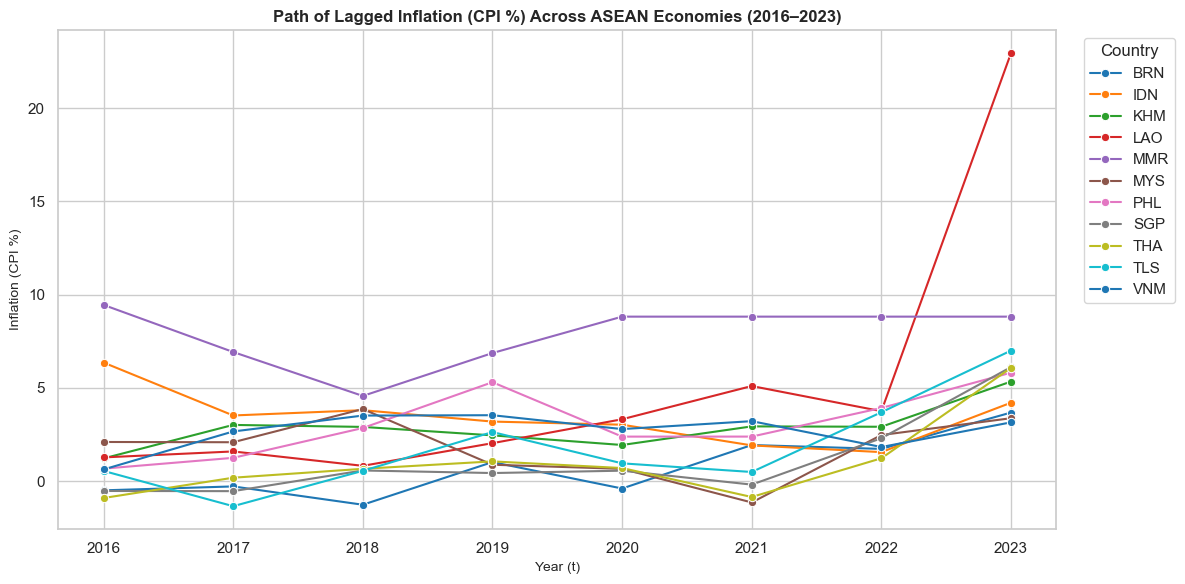

In [36]:
# Set visual style
sns.set_theme(style="whitegrid")

# Visualise macroeconomic Shock Over Time (Inflation & Current Account)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=final_df, 
    x='year', 
    y='Inflation (CPI %)_lag1', 
    hue='ISO3', 
    marker='o',
    palette='tab10'
)
plt.title("Path of Lagged Inflation (CPI %) Across ASEAN Economies (2016–2023)", fontsize=12, weight='bold')
plt.xlabel("Year (t)", fontsize=10)
plt.ylabel("Inflation (CPI %)", fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Country")
plt.tight_layout()
plt.savefig("appendix_inflation_trends.png", dpi=300)
plt.show()

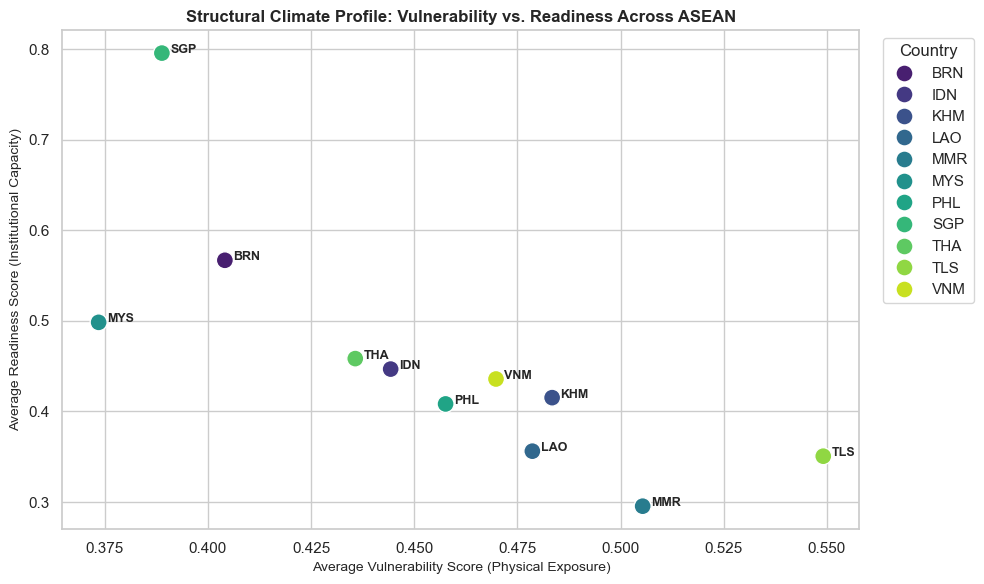

In [37]:
# Visualise the climate divide (Vulnerability vs. Readiness)
# Shows the structural positioning of countries using average values across the period
country_climate = final_df.groupby('ISO3')[['Vulnerability score', 'IMF-Adapted Readiness score']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=country_climate, 
    x='Vulnerability score', 
    y='IMF-Adapted Readiness score', 
    hue='ISO3', 
    s=150, 
    palette='viridis'
)

# Annotate country codes next to their points
for i, row in country_climate.iterrows():
    plt.text(row['Vulnerability score'] + 0.002, row['IMF-Adapted Readiness score'], row['ISO3'], fontsize=9, weight='bold')

plt.title("Structural Climate Profile: Vulnerability vs. Readiness Across ASEAN", fontsize=12, weight='bold')
plt.xlabel("Average Vulnerability Score (Physical Exposure)", fontsize=10)
plt.ylabel("Average Readiness Score (Institutional Capacity)", fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Country")
plt.tight_layout()
plt.savefig("appendix_climate_scatter.png", dpi=300)
plt.show()

# Data Modelling

In [38]:
# # Load necessary packages
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (70, 5)
Testing set shape:  (18, 5)


In [40]:
# Initiliase baseline decision tree
dt = DecisionTreeClassifier(random_state=42)
dt = dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
dt_score = accuracy_score(y_test, y_pred)
print(f"\nBaseline Decision Tree accuracy: {dt_score:.2%}")


Baseline Decision Tree accuracy: 77.78%


In [41]:
# Model Tuning
dt_clf = DecisionTreeClassifier(random_state=42)
dt_param_grid = {
    'max_depth': range(2, 8),          
    'min_samples_leaf': range(2, 10, 2),
    'min_samples_split': range(4, 20, 4),
}
dt_random_search = RandomizedSearchCV(
    estimator=dt_clf,
    param_distributions=dt_param_grid,
    n_iter=15,
    cv=5,              
    scoring='f1',       
    random_state=42,
)
dt_random_search.fit(X_train, y_train)
print(f"Best Decision Tree Parameters: {dt_random_search.best_params_}")
print(f"Best CV F1: {dt_random_search.best_score_:.3f}")

Best Decision Tree Parameters: {'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 7}
Best CV F1: 0.133


In [42]:
# Optimise best parameters
dt_best = dt_random_search.best_estimator_
y_pred_tuned = dt_best.predict(X_test)
dt_tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Decision Tree test accuracy: {dt_tuned_acc:.2%}")
confusion_matrix(y_test, y_pred_tuned)
print(classification_report(y_test, y_pred_tuned, zero_division=0))

Tuned Decision Tree test accuracy: 83.33%
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.50      0.33      0.40         3

    accuracy                           0.83        18
   macro avg       0.69      0.63      0.65        18
weighted avg       0.81      0.83      0.82        18



In [43]:
# Initialised baseline random forest
rf = RandomForestClassifier(random_state=42)
rf = rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_score = accuracy_score(y_test, y_pred_rf)
print(f"Baseline Random Forest accuracy: {rf_score:.2%}")

Baseline Random Forest accuracy: 83.33%


In [44]:
# Model Tuning
rf_clf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': range(100, 500, 100), 
    'max_depth': range(2, 8),
    'min_samples_leaf': range(2, 10, 2),
    'min_samples_split': range(4, 20, 4),
}
rf_random_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_grid,
    n_iter=15,
    cv=5,
    scoring='f1',
    random_state=42,
)
rf_random_search.fit(X_train, y_train)
print(f"\nBest Random Forest Parameters: {rf_random_search.best_params_}")
print(f"Best CV F1: {rf_random_search.best_score_:.3f}")


Best Random Forest Parameters: {'n_estimators': 100, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_depth': 6}
Best CV F1: 0.000


In [45]:
# Optimise best parameters
rf_best = rf_random_search.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test)
rf_tuned_acc = accuracy_score(y_test, y_pred_rf_tuned)
print(f"Tuned Random Forest test accuracy: {rf_tuned_acc:.2%}")
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred_rf_tuned, labels=[0, 1]))
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))

Tuned Random Forest test accuracy: 83.33%
Confusion matrix [[TN, FP], [FN, TP]]:
[[15  0]
 [ 3  0]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        15
           1       0.00      0.00      0.00         3

    accuracy                           0.83        18
   macro avg       0.42      0.50      0.45        18
weighted avg       0.69      0.83      0.76        18



In [46]:
# DT vs RF comparison
comparison = pd.DataFrame({
    'Decision Tree': [dt_score, dt_tuned_acc, dt_random_search.best_score_],
    'Random Forest': [rf_score, rf_tuned_acc, rf_random_search.best_score_],
}, index=['Baseline test accuracy', 'Tuned test accuracy', 'Best CV F1 (search objective)'])
print("\nModel comparison:")
print(comparison.round(3))


Model comparison:
                               Decision Tree  Random Forest
Baseline test accuracy                 0.778          0.833
Tuned test accuracy                    0.833          0.833
Best CV F1 (search objective)          0.133          0.000


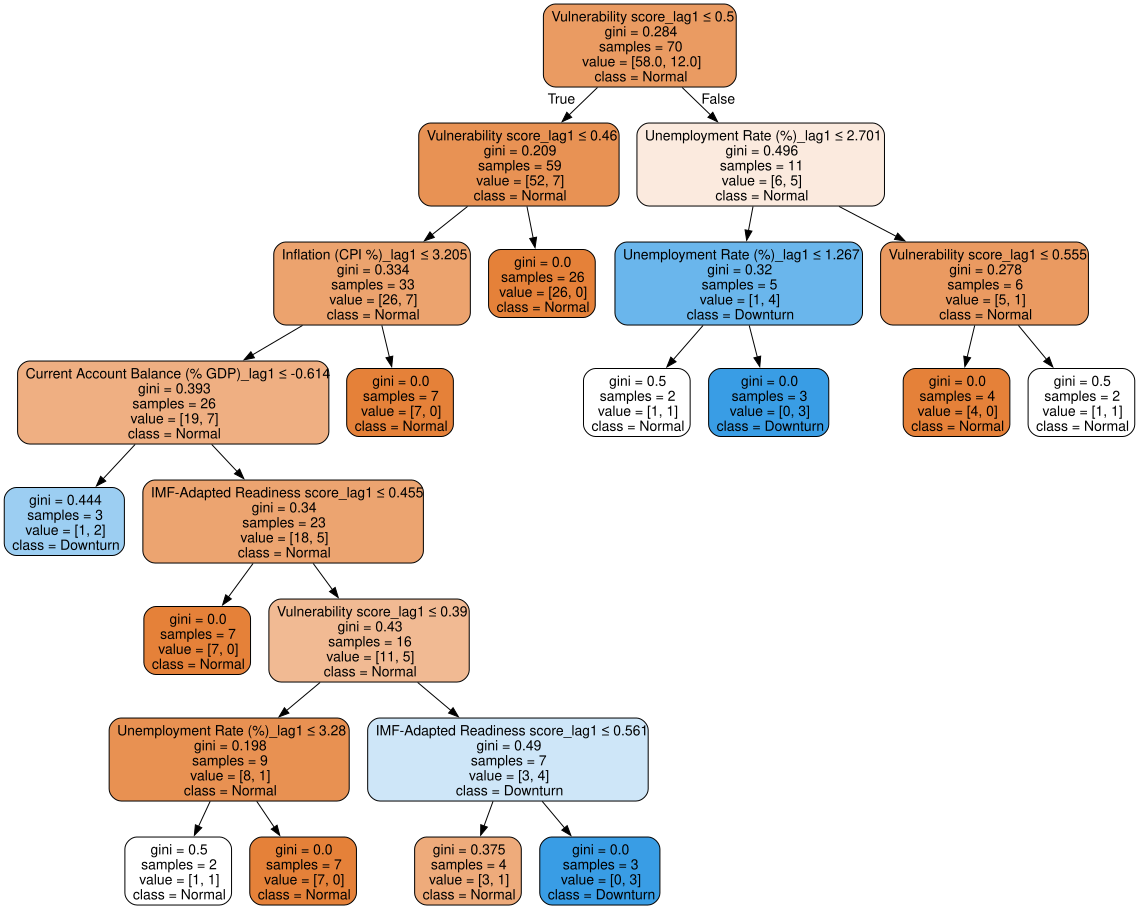

In [47]:
# Visualise the tree
from sklearn import tree
import graphviz

# Extract the best model
best_dt = dt_random_search.best_estimator_

file_name = 'asean_macro_dt.dot'
with open(file_name, 'w') as f:
    tree.export_graphviz(
        best_dt,                          
        out_file=f,
        feature_names=X.columns,   
        class_names=['Normal', 'Downturn'],  
        filled=True, 
        rounded=True, 
        special_characters=True,
    )

with open(file_name) as f:
    dot_graph = f.read()

# Display the graph
graphviz.Source(dot_graph)